In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")


In [2]:
from google.colab import files

uploaded = files.upload()  # This will prompt you to upload a file


Saving youtube_channel_real_performance_analytics.csv to youtube_channel_real_performance_analytics.csv


In [3]:
# Load the dataset
df = pd.read_csv("youtube_channel_real_performance_analytics.csv")


In [53]:
df

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%),Revenue per View,Engagement Rate
0,0,201.0,2016-06-02,0,2,6,2016,Thursday,0.024,723.0,...,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66,0.000024,4.364455
1,1,391.0,2016-06-10,8,10,6,2016,Friday,0.056,727.0,...,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85,0.000056,3.153860
2,2,133.0,2016-06-14,4,14,6,2016,Tuesday,0.014,76.0,...,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07,0.000014,3.949293
3,3,14.0,2016-06-29,15,29,6,2016,Wednesday,0.004,18.0,...,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60,0.000004,5.434288
4,4,45.0,2016-07-01,2,1,7,2016,Friday,0.000,0.0,...,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62,0.000000,4.495532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,359,779.0,2024-08-25,10,25,8,2024,Sunday,0.806,4104.0,...,50.82,396.0,10018.0,1104.5703,16.0,8.063,97065.0,8.23,0.000805,8.454781
360,360,818.0,2024-09-01,7,1,9,2024,Sunday,1.050,3273.0,...,42.05,344.0,8298.0,793.6508,7.0,8.705,65912.0,9.36,0.001049,7.724753
361,361,2233.0,2024-09-16,15,16,9,2024,Monday,1.161,3605.0,...,31.48,703.0,8487.0,1657.8232,14.0,9.852,76517.0,8.28,0.001161,9.284789
362,362,391.0,2024-09-25,9,25,9,2024,Wednesday,0.547,2338.0,...,62.38,244.0,7060.0,479.5583,11.0,3.858,67091.0,8.29,0.000546,7.577904


In [4]:
# Display basic information
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 70 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  364 non-null    int64  
 1   Video Duration                      364 non-null    float64
 2   Video Publish Time                  364 non-null    object 
 3   Days Since Publish                  364 non-null    int64  
 4   Day                                 364 non-null    int64  
 5   Month                               364 non-null    int64  
 6   Year                                364 non-null    int64  
 7   Day of Week                         364 non-null    object 
 8   Revenue per 1000 Views (USD)        364 non-null    float64
 9   Monetized Playbacks (Estimate)      364 non-null    float64
 10  Playback-Based CPM (USD)            364 non-null    float64
 11  CPM (USD)                           364 non-n

In [5]:

# Check for missing values
print(df.isnull().sum())


ID                         0
Video Duration             0
Video Publish Time         0
Days Since Publish         0
Day                        0
                          ..
Watch Time (hours)         0
Subscribers                0
Estimated Revenue (USD)    0
Impressions                0
Video Thumbnail CTR (%)    0
Length: 70, dtype: int64


In [6]:
# Preview the dataset
df.head()

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


In [8]:
!pip install isodate


In [9]:
# Drop rows with missing values (if any)
df = df.dropna()

# Convert 'Video Publish Time' to datetime format
df['Video Publish Time'] = pd.to_datetime(df['Video Publish Time'])

# Convert 'Video Duration' from ISO 8601 format to seconds (if needed)
import isodate
df['Video Duration'] = df['Video Duration'].apply(lambda x: isodate.parse_duration(x).total_seconds() if isinstance(x, str) else x)


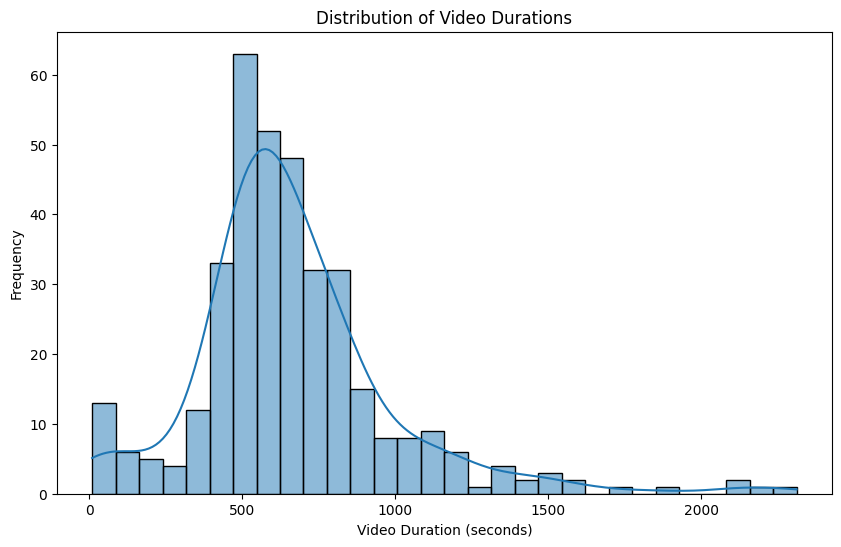

In [11]:
#EDA
#Visulaizing Video Duration Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Video Duration'], bins=30, kde=True)
plt.title('Distribution of Video Durations')
plt.xlabel('Video Duration (seconds)')
plt.ylabel('Frequency')
plt.show()


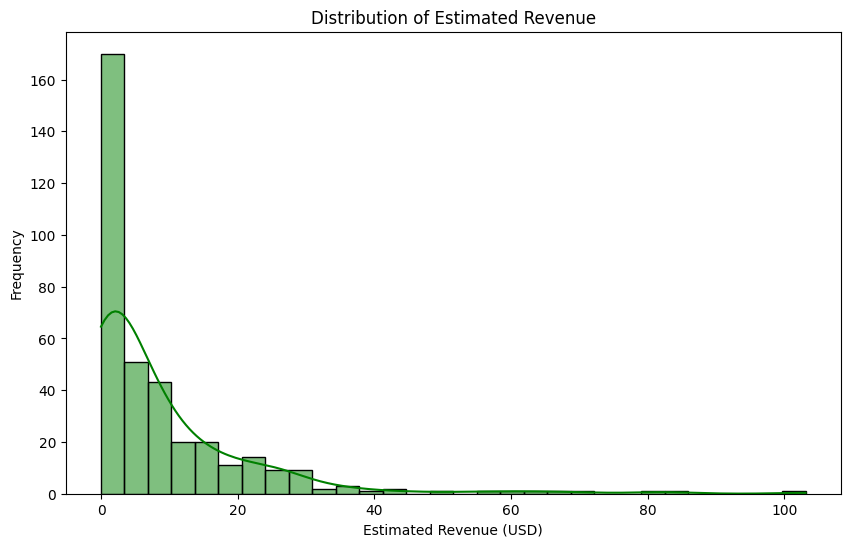

In [12]:
#Revenue Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Estimated Revenue (USD)'], bins=30, kde=True, color="green")
plt.title('Distribution of Estimated Revenue')
plt.xlabel('Estimated Revenue (USD)')
plt.ylabel('Frequency')
plt.show()


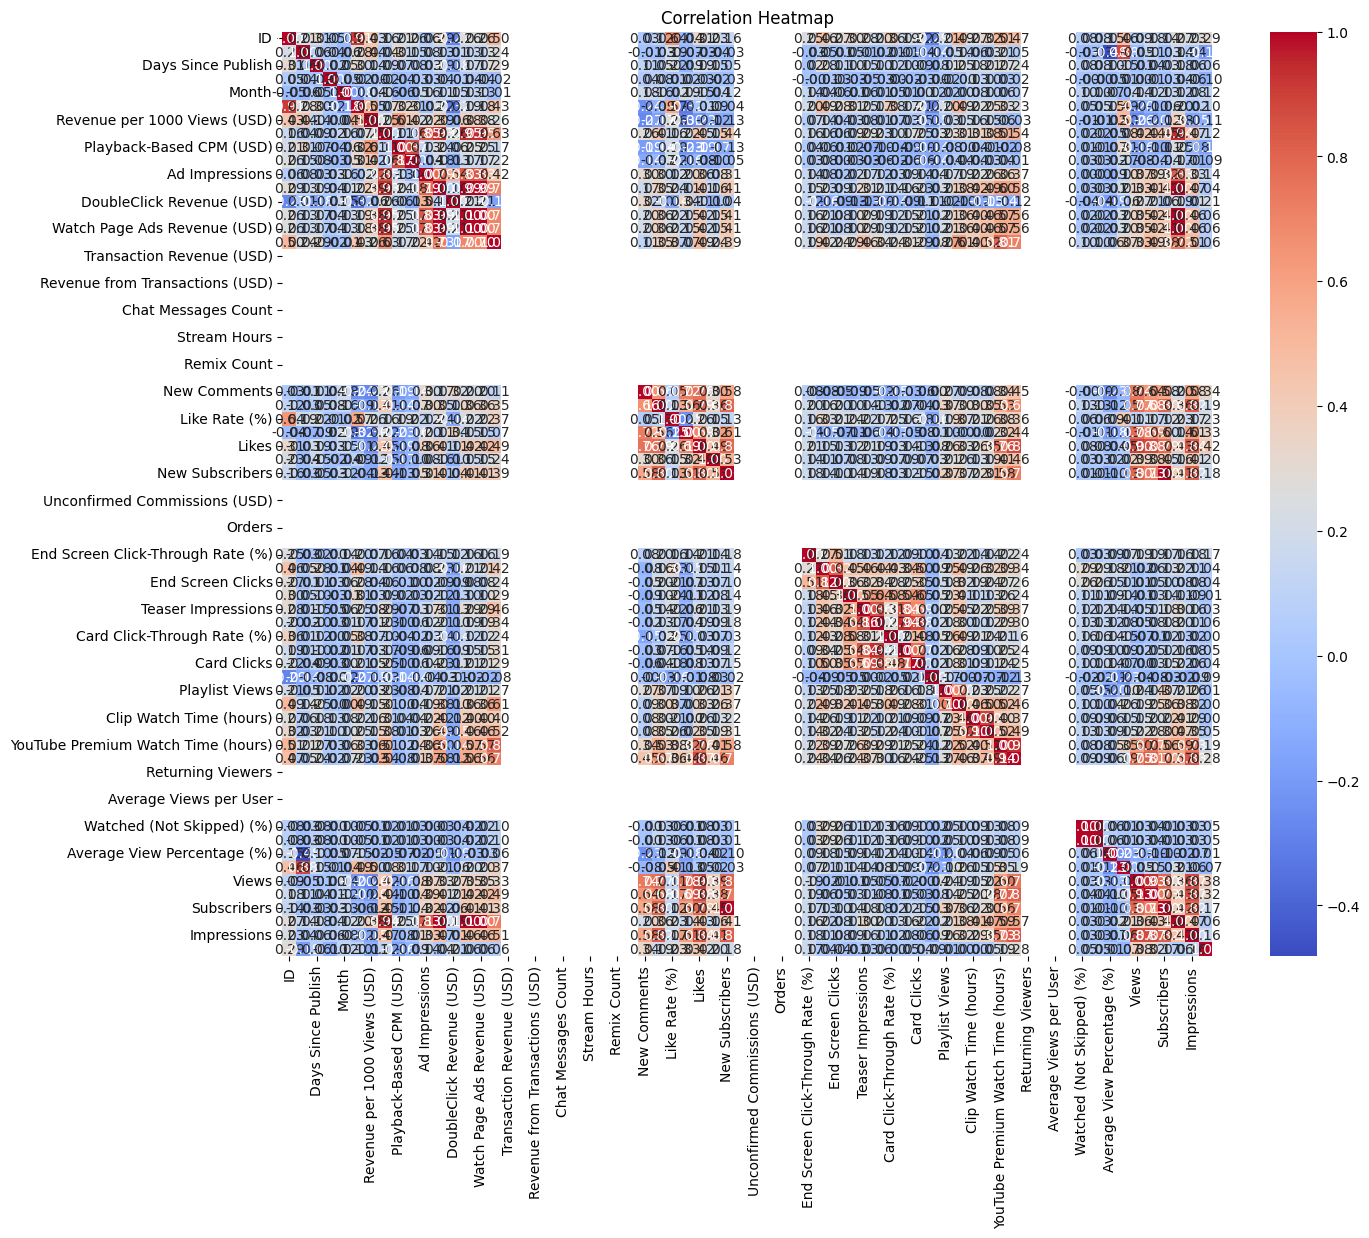

In [15]:
#Correlation Heatmap
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()



In [17]:
#Feature Engineering
print(df.columns)


Index(['ID', 'Video Duration', 'Video Publish Time', 'Days Since Publish',
       'Day', 'Month', 'Year', 'Day of Week', 'Revenue per 1000 Views (USD)',
       'Monetized Playbacks (Estimate)', 'Playback-Based CPM (USD)',
       'CPM (USD)', 'Ad Impressions', 'Estimated AdSense Revenue (USD)',
       'DoubleClick Revenue (USD)', 'YouTube Ads Revenue (USD)',
       'Watch Page Ads Revenue (USD)', 'YouTube Premium (USD)',
       'Transaction Revenue (USD)', 'Transactions',
       'Revenue from Transactions (USD)', 'Reactions', 'Chat Messages Count',
       'Reminders Set', 'Stream Hours', 'Remix Views', 'Remix Count',
       'Subscribers from Posts', 'New Comments', 'Shares', 'Like Rate (%)',
       'Dislikes', 'Likes', 'Unsubscribes', 'New Subscribers',
       'Returned Items (USD)', 'Unconfirmed Commissions (USD)',
       'Approved Commissions (USD)', 'Orders', 'Total Sales Volume (USD)',
       'End Screen Click-Through Rate (%)', 'End Screen Impressions',
       'End Screen Clicks', 

In [20]:
df['Engagement Rate'] = (df['Likes'] + df['Shares'] + df['New Comments']) / df['Views'] * 100


In [23]:
# Create Revenue per View
df['Revenue per View'] = df['Estimated Revenue (USD)'] / df['Views']

In [25]:
# Create Engagement Rate
df['Engagement Rate'] = (df['Likes'] + df['Shares'] + df['New Comments']) / df['Views'] * 100


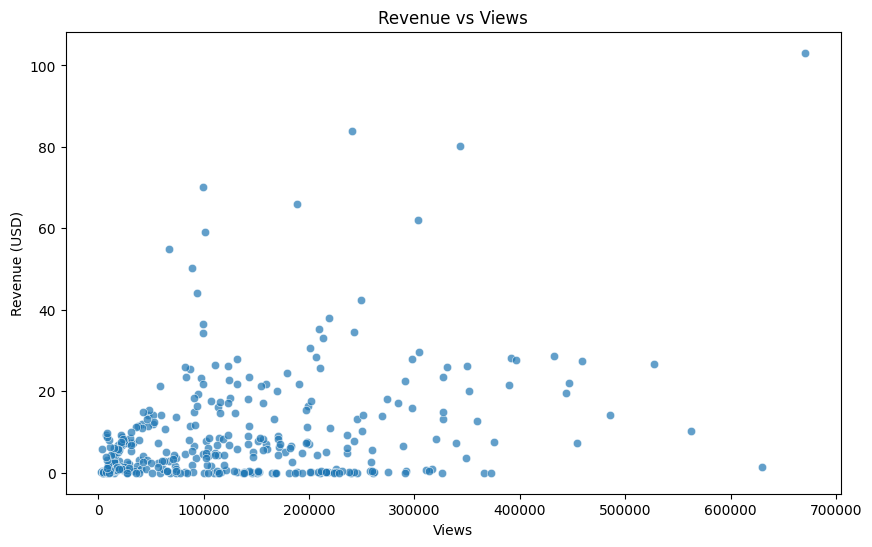

In [27]:
#Data Visualization
#revenue v/s Views
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Views'], y=df['Estimated Revenue (USD)'], alpha=0.7)
plt.title("Revenue vs Views")
plt.xlabel("Views")
plt.ylabel("Revenue (USD)")
plt.show()


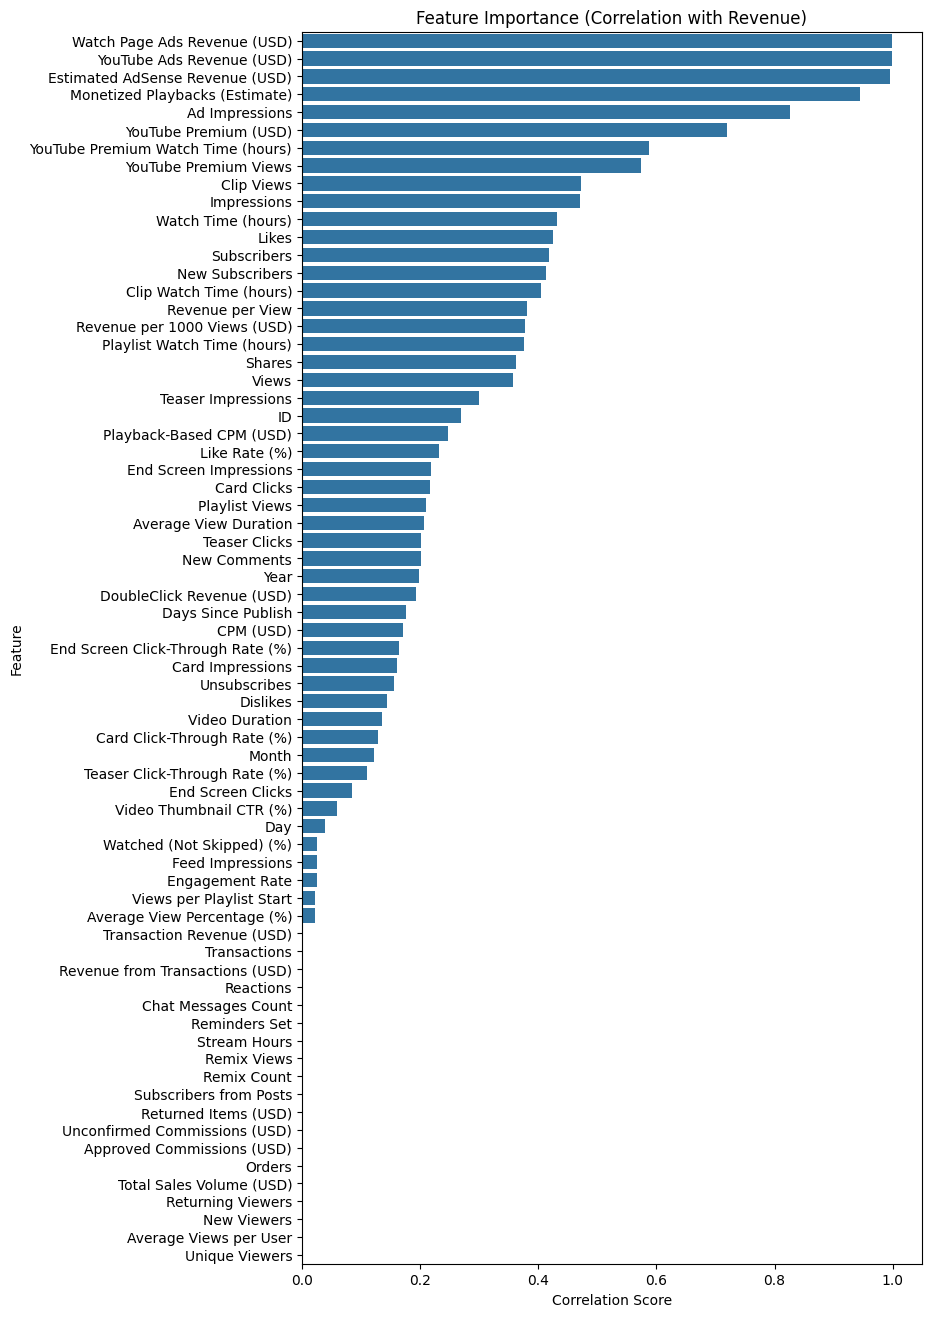

In [38]:
#Feature Importance
# Select only numeric columns
df_numeric = df.select_dtypes(include=['number'])

# Compute correlation with Estimated Revenue (USD)
corr_revenue = df_numeric.corr()['Estimated Revenue (USD)'].abs().sort_values(ascending=False)[1:]

# Plot Feature Importance
plt.figure(figsize=(8, 16))
sns.barplot(x=corr_revenue, y=corr_revenue.index)
plt.title("Feature Importance (Correlation with Revenue)")
plt.xlabel("Correlation Score")
plt.ylabel("Feature")
plt.show()



In [41]:
#Revenue Prediction
# Select features and target
features = ['Views', 'Subscribers', 'Likes', 'Shares', 'New Comments', 'Engagement Rate']  # Updated 'Comments' → 'New Comments'
target = 'Estimated Revenue (USD)'

X = df[features]
y = df[target]

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [42]:
#Train Model
# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)


In [43]:
print(y_pred)

[ 9.84094  2.26001  1.6979  10.05815 17.34421  9.78185  0.88528  8.70682
 12.31788  7.8314   5.37407  0.84694 10.73967  1.67385  6.64856 17.63241
  2.51002  3.36591  7.36498 18.72365  0.34165 24.66753 10.95469  6.59723
 10.14843 26.72633  6.81269 12.21399  2.02326  2.23052  9.68335 16.78327
  2.07929  5.72839 27.81797 17.55691  0.81059  1.64627  7.83045  3.77156
 18.39601  4.53202  2.84179  6.72232 17.71107  4.63446 11.80163  0.48949
  0.54626  1.96857 15.45904  3.86452 20.73537  5.99864 12.95955  7.52469
  4.97479  0.32348  1.29366  1.08382 16.23998 16.95342  2.94647  1.80327
  9.13293  1.11176  1.41919  5.17432  3.44339  8.82152  6.13839 15.20794
 21.32125]


In [44]:
# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")


Mean Squared Error: 75.70
R-squared Score: 0.13


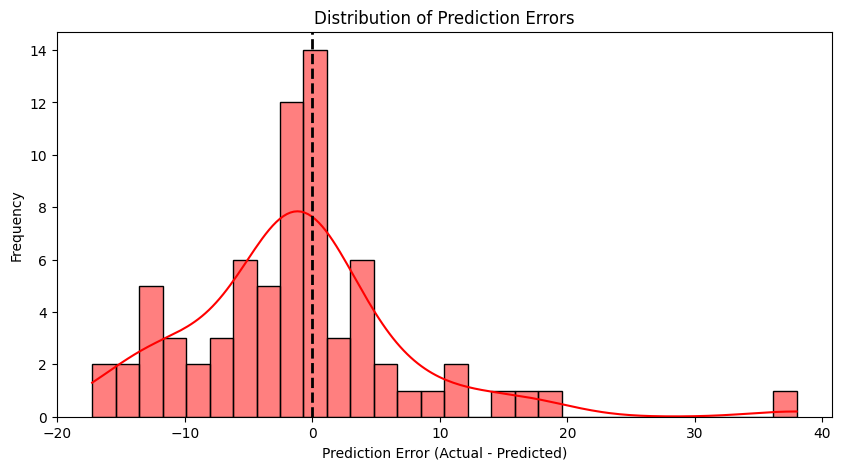

In [46]:
# Compute errors
errors = y_test - y_pred

# Plot histogram
plt.figure(figsize=(10, 5))
sns.histplot(errors, bins=30, kde=True, color="red")
plt.axvline(0, color='black', linestyle='dashed', linewidth=2)  # Zero error line
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()

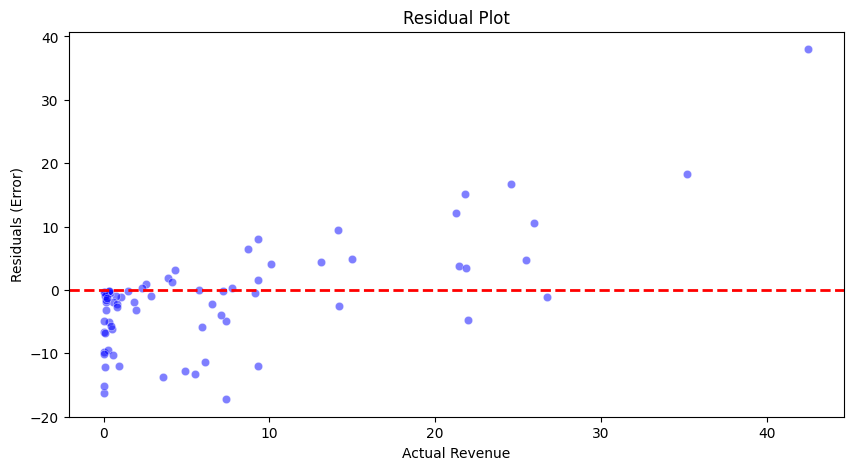

In [47]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test, y=errors, alpha=0.5, color="blue")
plt.axhline(0, color='red', linestyle='dashed', linewidth=2)  # Zero error line
plt.xlabel("Actual Revenue")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.show()


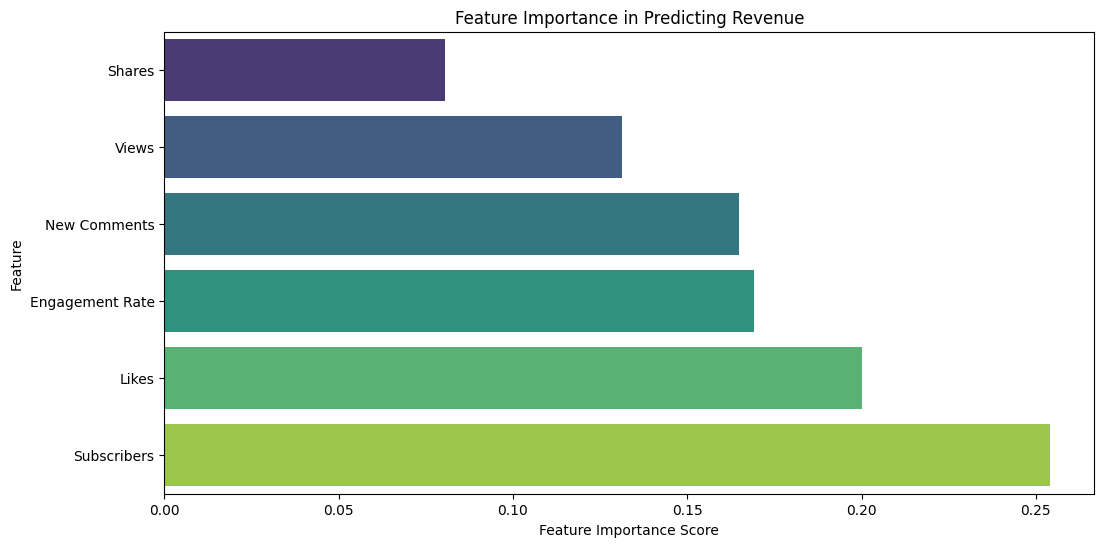

In [48]:
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
importance_df = importance_df.sort_values(by="Importance", ascending=True)

# Plot feature importances
plt.figure(figsize=(12, 6))
sns.barplot(x=importance_df["Importance"], y=importance_df["Feature"], palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance in Predicting Revenue")
plt.show()


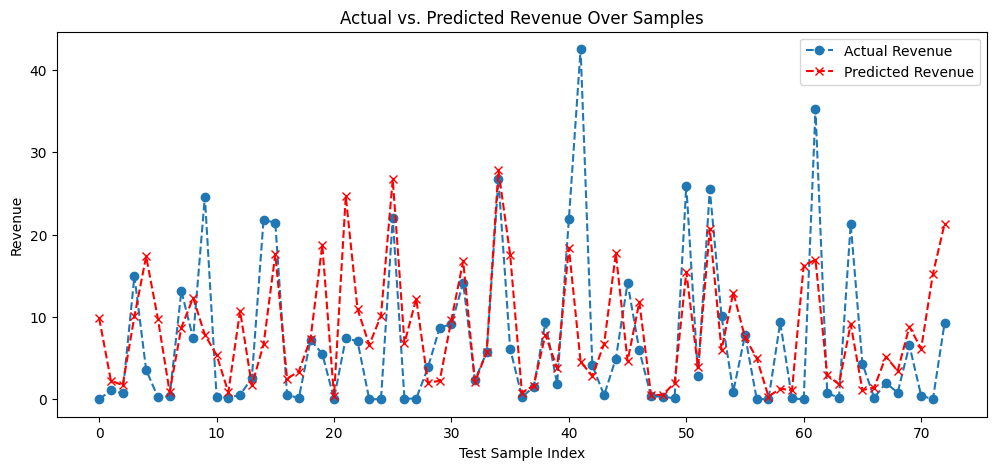

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual Revenue", marker="o", linestyle="dashed")
plt.plot(y_pred, label="Predicted Revenue", marker="x", linestyle="dashed", color="red")
plt.xlabel("Test Sample Index")
plt.ylabel("Revenue")
plt.title("Actual vs. Predicted Revenue Over Samples")
plt.legend()
plt.show()


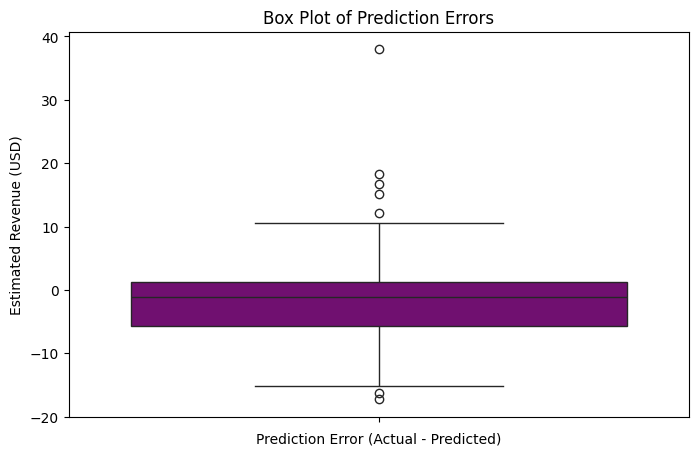

In [50]:
plt.figure(figsize=(8, 5))
sns.boxplot(errors, color="purple")
plt.title("Box Plot of Prediction Errors")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.show()


In [52]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# Convert data to DataFrame if needed
df_results = pd.DataFrame({'Actual Revenue': y_test, 'Predicted Revenue': y_pred})

# 1. Interactive Scatter Plot (Actual vs Predicted Revenue)
fig1 = px.scatter(df_results, x='Actual Revenue', y='Predicted Revenue', trendline='ols',
                   title='Actual vs. Predicted Revenue', opacity=0.7)
fig1.show()

# 2. Interactive Residual Plot
residuals = y_test - y_pred
fig2 = px.scatter(x=y_test, y=residuals, labels={'x': 'Actual Revenue', 'y': 'Residuals'},
                  title='Residual Plot (Errors in Prediction)')
fig2.add_hline(y=0, line_dash='dash', line_color='red')
fig2.show()

# 3. Feature Importance Bar Chart
importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=True)
fig3 = px.bar(importance_df, x='Importance', y='Feature', orientation='h',
              title='Feature Importance in Predicting Revenue')
fig3.show()

# 4. Interactive Line Plot (Actual vs Predicted over Test Samples)
df_results['Index'] = df_results.index
fig4 = go.Figure()
fig4.add_trace(go.Scatter(x=df_results['Index'], y=df_results['Actual Revenue'], mode='lines+markers', name='Actual Revenue'))
fig4.add_trace(go.Scatter(x=df_results['Index'], y=df_results['Predicted Revenue'], mode='lines+markers', name='Predicted Revenue', line=dict(dash='dash')))
fig4.update_layout(title='Actual vs Predicted Revenue Over Samples', xaxis_title='Test Sample Index', yaxis_title='Revenue')
fig4.show()

# 5. Box Plot for Prediction Errors
fig5 = px.box(y=residuals, title='Box Plot of Prediction Errors', labels={'y': 'Prediction Error'})
fig5.show()
